In [1]:
import pandas as pd

from matplotlib import pyplot as plt
%matplotlib inline
plt.rcParams["font.family"] = "Arial"

from upsetplot import UpSet

# Loading and Processing Meta Data

In [2]:
# meta = pd.read_csv(
#     "../../data/fay_meta_nov_upset.csv", index_col=0
# )  ## meta after Qiime2 processing


meta = pd.read_csv(
    "../../data/fay_meta_diets.csv", index_col=0
)  ## meta after all processing (used for all analysis)

In [3]:
meta.shape

(978, 196)

## Upset plot with Catplots

In [4]:
def add_above_average_indicators(data_df, top_features, quantile_threshold=0.50):
    """
    Adds binary indicators to the DataFrame indicating whether each of
    the top features is above the median for that feature.

    Parameters:
    - data_df: The original pandas DataFrame.
    - top_features: A list of strings representing the column names for the top features.

    Returns:
    - A modified DataFrame with additional columns indicating whether the values of the top features
      are above their respective medians and sets these indicators as part of the index.
    """
    # Ensure the top_features are within the DataFrame columns
    top_features = [feature for feature in top_features if feature in data_df.columns]
    print(top_features)

    # Compute whether each value is above the median for its column
    # above_df = data_df[top_features] > data_df[top_features].median()
    above_df = data_df[top_features] > data_df[top_features].quantile(
        quantile_threshold
    )

    # Rename the columns to indicate these are 'above median' indicators
    above_df = above_df.rename(columns=lambda x: x + " > median")

    # Concatenate the original DataFrame with the new binary indicators
    updated_df = pd.concat([data_df, above_df], axis=1)

    # Set the new binary indicators as part of the index
    updated_df = updated_df.set_index(list(above_df.columns))

    return updated_df

In [5]:
upset_feats = [
    "fast_food_fg_eaten",
    "meat_fg_eaten",
    "fiber_eaten",
    "vegetables_fruits",
]
meta_upset = add_above_average_indicators(meta, upset_feats, quantile_threshold=0.50)

## Renaming the columns for better visualization
meta_upset.rename(
    columns={
        "age": "Age",
        "bmi": "BMI",
        "shannon_entropy": "Shannon",
    },
    inplace=True,
)

meta_upset.index.names = [
    "Fast foods eaten > median",
    "Meat eaten > median",
    "Fiber eaten > median",
    "Vegetables/Fruits > median",
]

meta_upset

['fast_food_fg_eaten', 'meat_fg_eaten', 'fiber_eaten', 'vegetables_fruits']


subject_app_key  \
Fast foods eaten > median Meat eaten > median Fiber eaten > median Vegetables/Fruits > median                   
True                      False               True                 True                                ce3m4w   
False                     True                False                False                               qrh38g   
                          False               True                 True                                kz2eh8   
True                      False               True                 False                               curus8   
False                     True                True                 True                                qf5fwf   
...                                                                                                       ...   
True                      False               False                False                               qda49t   
                          True                False                False                               phzbkm   
                                                                   False                               mbrack   
                          False               False                False                               m93aw9   
                          True                False                False                               4yvhe5   

                                                                                               start_date  \
Fast foods eaten > median Meat eaten > median Fiber eaten > median Vegetables/Fruits > median               
True                      False               True                 True                        2022-02-11   
False                     True                False                False                       2022-10-23   
                          False               True                 True                        2020-09-27   
True                      False               True                 False                       2023-01-12   
False                     True                True                 True                        2021-06-11   
...                                                                                                   ...   
True                      False               False                False                       2023-02-02   
                          True                False                False                       2023-01-22   
                                                                   False                       2023-01-21   
                          False               False                False                       2023-01-22   
                          True                False                False                       2023-01-22   

                                                                                                birthdate  \
Fast foods eaten > median Meat eaten > median Fiber eaten > median Vegetables/Fruits > median               
True                      False               True                 True                        2002-06-12   
False                     True                False                False                       1979-05-05   
                          False               True                 True                        1987-03-19   
True                      False               True                 False                       1994-12-05   
False                     True                True                 True                        1988-11-23   
...                                                                                                   ...   
True                      False               False                False                       1968-04-24   
                          True                False                False                       1993-01-11   
                                                                   False                       1997-08-22   
       

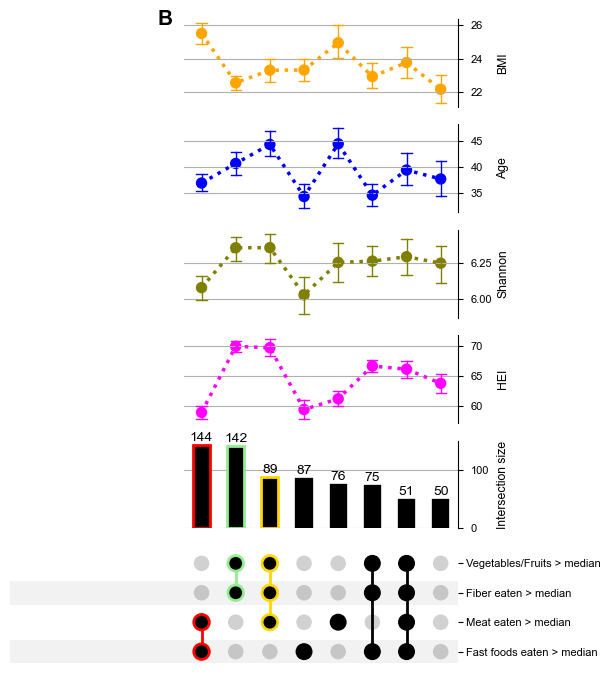

In [6]:
upset = UpSet(
    meta_upset,
    subset_size="count",
    totals_plot_elements=0,
    intersection_plot_elements=3,
    show_counts=True,
    show_percentages=False,
    orientation="horizontal",
    facecolor="black",
    min_subset_size=50,
    sort_by="cardinality",
)

upset.style_subsets(
    present=["Vegetables/Fruits > median", "Fiber eaten > median"],
    absent=["Fast foods eaten > median", "Meat eaten > median"],
    edgecolor="lightgreen",
    linewidth=2,
)

upset.style_subsets(
    present=["Meat eaten > median", "Fast foods eaten > median"],
    absent=["Vegetables/Fruits > median", "Fiber eaten > median"],
    edgecolor="red",
    linewidth=2,
)

upset.style_subsets(
    present=[
        "Meat eaten > median",
        "Vegetables/Fruits > median",
        "Fiber eaten > median",
    ],
    absent=["Fast foods eaten > median"],
    edgecolor="gold",
    linewidth=2,
)

plot_kws = {
    "markers": "o",
    "linestyles": "dotted",
    "errwidth": 1,
    "capsize": 0.3,
    "join": True,
    "estimator": "mean",
}

upset.add_catplot(value="HEI", kind="point", elements=3, color="magenta", **plot_kws)
upset.add_catplot(value="Shannon", kind="point", elements=3, color="olive", **plot_kws)
upset.add_catplot(value="Age", kind="point", elements=3, color="blue", **plot_kws)
upset.add_catplot(value="BMI", kind="point", elements=3, color="orange", **plot_kws)

with plt.style.context("seaborn-paper"):
    upset.plot()
    plt.text(
        -0.1,
        1.1,
        "B",
        transform=plt.gca().transAxes,
        fontsize=15,
        verticalalignment="top",
        horizontalalignment="left",
        weight="bold",
    )

    # Access the scatter plot axes and move y-axis labels and spine to the right
    fig = plt.gcf()
    for ax in fig.axes:
        if hasattr(ax, "collections"):
            ax.yaxis.set_label_position("right")
            ax.yaxis.tick_right()
            ax.spines["right"].set_position(("outward", 0))
            ax.spines["left"].set_color("none")
            ax.spines["right"].set_visible(True)
            ax.spines["right"].set_color("black")

    plt.savefig(
        "../../figures/gut_diversity_analysis/upset_plot.png",
        dpi=300,
        bbox_inches="tight",
    )